# Paired-pulse (AP1/AP2) analysis: Control vs PS-blocked


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, FixedLocator
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.optimize import curve_fit, minimize_scalar, minimize

from plot_config import (
    apply_style, strip_spines, save_figure, CONDITIONS, get_condition,
    set_n_ticks, set_nice_ticks, add_zoom_inset, label_panel,
)

apply_style()

# ============================================================
#                     USER SETTINGS
# ============================================================

CTRL_DIR = Path(
    "/data/hdrive/phd/results/prvsppf_experiments/MI_cont/"
    "RSI40V80C250uM_nish2sur_nishRyR"
)

AD_DIR = Path(
    "/data/hdrive/phd/results/prvsppf_experiments/AD_PSblocked_vdcc_vs_ppf/"
    "RSI40V80C750uM_nish2sur_nishRyR_PSblocked"
)

DIRS = {"control": CTRL_DIR, "ad_ps_blocked": AD_DIR}

SAVE_FIGS = True
LABEL_FS, TICK_FS, LEG_FS = 12, 10, 9


T_STIM1_MS, T_STIM2_MS = 0.0, 40.0
T_END = 0.07 

# Peak-search robustness: VDCC's flux peak can land within ~1 sample of
# t_stim itself (channel opens almost instantly), so a strictly-forward
# search from t_stim risks missing it entirely if it lands a hair earlier.
# This buffer only matters in that edge case -- for every other signal
# (which peaks measurably after t_stim) it has no effect on the result.
PEAK_SEARCH_BUFFER_S = 0.0015

COND_LW = {"control": 1.8, "ad_ps_blocked": 2.6}

FIT_COLOR = {"control": "#E69F00", "ad_ps_blocked": "#0072B2"}

# Zoom-inset window width for the calcium-pool trace-comparison figure --
# one inset per AP, each spanning [AP_start, AP_start + 5ms].
INSET_WINDOW_MS = 5.0

RYR_FLUX_SCALE = 1e-6


def load(data_dir, fname, usecols=None):
    return np.genfromtxt(data_dir / fname, usecols=usecols)


def log_ticks_3(vmax, vmin=1.0):
    """3 round-power-of-ten ticks spanning [vmin, vmax], roughly evenly
    log-spaced -- automates the manual [1, 1e4, 1e7] / [0.1, 1, 10] choices
    in fig3_single_AP.ipynb / figS1_model_fits_timescales.ipynb."""
    lo = int(np.floor(np.log10(max(vmin, 1e-6))))
    hi = int(np.ceil(np.log10(max(vmax, vmin * 10))))
    mid = round((lo + hi) / 2)
    return [10.0 ** lo, 10.0 ** mid, 10.0 ** hi]


def set_log_yticks(ax, vmax, vmin=1.0):
    ax.set_yticks(log_ticks_3(vmax, vmin))
    ax.yaxis.set_minor_locator(NullLocator())


# ------------------------------------------------------------------
# Pr(AP1) vs Facilitation (VDCC sweep) -- shared by Section 5's panel i
# and Section 6's standalone figure.
# ------------------------------------------------------------------
PR_PPF_FILES = {
    "Control": Path(
        "/data/hdrive/phd/results/prvsppf_experiments/pr vs ppf/I40_prvsppf_control_0_8serca"
    ),
    "PSblocked (ER calcium=750 μM)": Path(
        "/data/hdrive/phd/results/prvsppf_experiments/pr vs ppf/I40_prvsppf_PSblocked_0_8serca"
    ),
    "PSblocked (ER calcium=250 μM)": Path(
        "/data/hdrive/phd/results/prvsppf_experiments/pr vs ppf/I40_prvsppf_cont_PSblocked"
    ),
}

PR_PPF_COLORS = {
    "Control": "#000000",
    "PSblocked (ER calcium=750 μM)": "#CC79A7",
    "PSblocked (ER calcium=250 μM)": "#56B4E9",
}

VDCC_HIGHLIGHT = [80, 90]
VDCC_COLORS = {80: "#009E73", 90: "#D55E00"}

ARROW_OFFSETS = {80: (-24, 16), 90: (20, -20)}

# Dobrunz & Stevens (1997), Neuron 18:995-1008, Fig 3A -- experimental
# Pr1-vs-Facilitation benchmark (n=38 hippocampal CA3-CA1 synapses, 40 ms
# interpulse interval). Only the authors' own reported fit is drawn (not
# a local refit of digitized points -- see RyR_expression_levels.ipynb for
# the full digitization); curve spans their own stated Pr1 data range.
DOBRUNZ_STEVENS_1997_PARAMS = (1.24, -0.41)  # u(t), v_beta from their Results
DOBRUNZ_STEVENS_1997_PR1_RANGE = (0.052, 0.859)

PR1PPF_YLIM = (0, 7)


def load_pr_ppf(fname):
    """Plain-text table, header line starts with `//`: VDCC, pr1, sd-pr1,
    pr2, sd-pr2, ppf, sd-ppf."""
    data = np.loadtxt(fname, comments="//")
    vdcc = data[:, 0].astype(int)
    pr1 = data[:, 1]
    facilitation = data[:, 5]
    facilitation_sd = data[:, 6]
    return vdcc, pr1, facilitation, facilitation_sd


def facilitation_model(x, a, b):
    """Saturating-recovery fit of Facilitation vs Pr(AP1)"""
    return (1 - (1 - x) ** (a * x ** b)) / x


def draw_pr_ppf_panel(ax, legend_fontsize=LEG_FS, legend_compact=False,
                       show_condition_legend=True, xlabel="Pr (AP1)",
                       ylabel="Facilitation"):
    """Draws the Pr(AP1)-vs-Facilitation curves (errorbar + facilitation_model
    fit + VDCC=80/90 arrows) for all three conditions onto `ax`. Shared by
    Section 5 panel i (compact) and Section 6's standalone figure (full size)
    so the two never drift apart. `show_condition_legend=False` skips the
    in-panel Condition legend (used by panel i, whose Condition legend is
    drawn once at the top of the whole figure instead); `xlabel`/`ylabel`
    override the axis text for one caller without touching the other."""
    print("Pr(AP1) vs Facilitation: facilitation_model fit quality")
    for label, fname in PR_PPF_FILES.items():
        vdcc, pr1, facilitation, facilitation_sd = load_pr_ppf(fname)
        color = PR_PPF_COLORS[label]

        ax.errorbar(pr1, facilitation, yerr=facilitation_sd, fmt='o', color=color,
                    markersize=4 if legend_compact else 5, capsize=3,
                    linewidth=1.0 if legend_compact else 1.2, alpha=0.85, zorder=2, label=label)

        params, _ = curve_fit(facilitation_model, pr1, facilitation, maxfev=10000)
        pred = facilitation_model(pr1, *params)
        r2 = 1 - np.sum((facilitation - pred) ** 2) / np.sum((facilitation - facilitation.mean()) ** 2)
        print(f"  {label}: R²={r2:.3f}")

        xfit = np.linspace(pr1.min(), pr1.max(), 400)
        yfit = facilitation_model(xfit, *params)
        ax.plot(xfit, yfit, color=color, lw=2.0 if legend_compact else 2.5, zorder=3)

        for v in VDCC_HIGHLIGHT:
            matches = np.where(vdcc == v)[0]
            if not len(matches):
                print(f"  {label}: VDCC={v} not found, skipping arrow")
                continue
            idx = matches[0]
            x_mark, y_mark = pr1[idx], facilitation[idx]
            dx, dy = ARROW_OFFSETS[v]
            if legend_compact:
                dx, dy = dx * 0.6, dy * 0.6
            ax.annotate(
                "", xy=(x_mark, y_mark), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                arrowprops=dict(arrowstyle="-|>", color=VDCC_COLORS[v],
                                 lw=1.4 if legend_compact else 1.8,
                                 shrinkA=0, shrinkB=2, mutation_scale=10 if legend_compact else 14),
                zorder=5,
            )

    ds_cond = get_condition("dobrunz_stevens_1997")
    xfit_ds = np.linspace(*DOBRUNZ_STEVENS_1997_PR1_RANGE, 400)
    yfit_ds = facilitation_model(xfit_ds, *DOBRUNZ_STEVENS_1997_PARAMS)
    ax.plot(xfit_ds, yfit_ds, color=ds_cond.color, linestyle=ds_cond.linestyle,
            lw=2.0 if legend_compact else 2.5, zorder=3, label=ds_cond.label)

    ax.set_xlabel(xlabel, fontsize=LABEL_FS)
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_ylim(*PR1PPF_YLIM)
    strip_spines(ax)
    set_nice_ticks(ax, *ax.get_xlim(), n=3, axis="x")
    set_nice_ticks(ax, *PR1PPF_YLIM, n=3, axis="y")

    if show_condition_legend:
        cond_handles, cond_labels = ax.get_legend_handles_labels()
        leg1 = ax.legend(cond_handles, cond_labels, loc="upper right", frameon=False,
                          fontsize=legend_fontsize, title="Condition", title_fontsize=legend_fontsize,
                          handlelength=1.2 if legend_compact else 2.0,
                          labelspacing=0.25 if legend_compact else 0.5,
                          borderaxespad=0.3)
        ax.add_artist(leg1)

    vdcc_handles = [Line2D([0], [0], marker='v', color='none', markerfacecolor=VDCC_COLORS[v],
                            markeredgecolor='black', markersize=8 if legend_compact else 10,
                            label=f"VDCC={v}")
                    for v in VDCC_HIGHLIGHT]
    # When the Condition legend is also drawn here, stack this one below
    # it in the upper-right, not lower-left -- with y clipped to (0, 7),
    # the curves are still well above the lower-left corner in the
    # low-Pr1/high-Facilitation region but have already dropped low by the
    # time Pr1 is large enough to sit under the right margin, so
    # upper-right stays clear for both legends. When the Condition legend
    # is suppressed (panel i -- its Condition legend now lives at the top
    # of the whole figure instead), this is the only legend on `ax`, so it
    # sits at the plain upper-right anchor instead of the stacked offset.
    vdcc_anchor = (1.0, 0.72) if show_condition_legend else (1.0, 1.0)
    ax.legend(handles=vdcc_handles, loc="upper right", bbox_to_anchor=vdcc_anchor,
              frameon=False,
              fontsize=legend_fontsize, title="Highlighted VDCC", title_fontsize=legend_fontsize,
              handlelength=1.2 if legend_compact else 2.0,
              labelspacing=0.25 if legend_compact else 0.5,
              borderaxespad=0.3)


results = []  # one dict per extracted timescale -> summary table at the end


## Helper functions



In [2]:
def smooth(x, win):
    """Centered moving-average smoothing (win = # samples, forced odd)."""
    if win <= 1:
        return x
    if win % 2 == 0:
        win += 1
    kernel = np.ones(win) / win
    pad = win // 2
    xp = np.pad(x, pad, mode='edge')
    return np.convolve(xp, kernel, mode='valid')


def time_to_peak(t, y, idx_start):
    seg = y[idx_start:]
    idx = np.argmax(seg) + idx_start
    return t[idx], y[idx], idx


def rise_time_10_90(t, y, idx_start, idx_peak, baseline):
    """Time between 10% and 90% of (peak-baseline) on the rising edge."""
    peak = y[idx_peak]
    lo = baseline + 0.10 * (peak - baseline)
    hi = baseline + 0.90 * (peak - baseline)
    seg_t = t[idx_start:idx_peak + 1]
    seg_y = y[idx_start:idx_peak + 1]
    if len(seg_y) < 2:
        return np.nan
    order = np.argsort(seg_y)
    t_lo = np.interp(lo, seg_y[order], seg_t[order])
    t_hi = np.interp(hi, seg_y[order], seg_t[order])
    return t_hi - t_lo


def decay_time_to_fraction(t, y, idx_peak, baseline, frac=1/np.e, idx_end=None):
    """Model-free decay time constant: time from peak to the first crossing
    of baseline + frac*(peak-baseline). frac=1/e mimics a single-exponential tau."""
    peak = y[idx_peak]
    target = baseline + frac * (peak - baseline)
    idx_end = len(y) if idx_end is None else idx_end
    seg = y[idx_peak:idx_end]
    cross = np.where(seg <= target)[0] if peak > baseline else np.where(seg >= target)[0]
    if len(cross) == 0:
        return np.nan
    idx_c = idx_peak + cross[0]
    if idx_c == idx_peak:
        return 0.0
    y0, y1, t0, t1 = y[idx_c - 1], y[idx_c], t[idx_c - 1], t[idx_c]
    frac_step = 0.0 if y1 == y0 else (target - y0) / (y1 - y0)
    return (t0 + frac_step * (t1 - t0)) - t[idx_peak]


def detect_onset(t, y, idx_search_start, idx_search_end, frac=0.05, rising=True):
    """First index where y departs from its pre-onset baseline by `frac` of
    its eventual total excursion."""
    baseline = np.median(y[max(0, idx_search_start - 50):idx_search_start]) if idx_search_start > 0 else y[0]
    y_ref = y[idx_search_end]
    thresh = baseline + frac * (y_ref - baseline)
    seg = y[idx_search_start:idx_search_end]
    cross = np.where(seg >= thresh)[0] if y_ref > baseline else np.where(seg <= thresh)[0]
    return idx_search_start + cross[0] if len(cross) else idx_search_start


# ---------------- relaxation fits (optionally relative-error weighted) ----------------

def _exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def _exp_rise(t, A, tau, C):
    return A * (1 - np.exp(-t / tau)) + C


def _biexp_decay(t, A1, tau1, A2, tau2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C


def _sigma_for(yy, weighted):
    return np.clip(np.abs(yy), 1.0, None) if weighted else None


def fit_exp_decay(t, y, idx_peak, idx_end, p0_tau, fix_zero_baseline=False, weighted=False):
    tt, yy = t[idx_peak:idx_end] - t[idx_peak], y[idx_peak:idx_end]
    if len(tt) < 5:
        return None
    sigma = _sigma_for(yy, weighted)
    try:
        if fix_zero_baseline:
            def f(t, A, tau):
                return A * np.exp(-t / tau)
            popt, pcov = curve_fit(f, tt, yy, p0=[yy[0], p0_tau], sigma=sigma, maxfev=20000,
                                    bounds=([-np.inf, 1e-7], [np.inf, np.inf]))
            perr = np.sqrt(np.diag(pcov))
            return dict(A=popt[0], tau=popt[1], C=0.0, tau_err=perr[1],
                        fit_t=tt, fit_y=f(tt, *popt))
        popt, pcov = curve_fit(_exp_decay, tt, yy, p0=[yy[0] - yy[-1], p0_tau, yy[-1]], sigma=sigma,
                                maxfev=20000, bounds=([-np.inf, 1e-7, -np.inf], [np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        return dict(A=popt[0], tau=popt[1], C=popt[2], tau_err=perr[1],
                    fit_t=tt, fit_y=_exp_decay(tt, *popt))
    except Exception:
        return None


def fit_exp_rise(t, y, idx_start, idx_end, p0_tau, weighted=False):
    tt, yy = t[idx_start:idx_end] - t[idx_start], y[idx_start:idx_end]
    if len(tt) < 5:
        return None
    sigma = _sigma_for(yy - yy[0], weighted)
    try:
        popt, pcov = curve_fit(_exp_rise, tt, yy, p0=[yy[-1] - yy[0], p0_tau, yy[0]], sigma=sigma,
                                maxfev=20000, bounds=([-np.inf, 1e-7, -np.inf], [np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        return dict(A=popt[0], tau=popt[1], C=popt[2], tau_err=perr[1],
                    fit_t=tt, fit_y=_exp_rise(tt, *popt))
    except Exception:
        return None


def fit_biexp_decay(t, y, idx_peak, idx_end, p0_tau1, p0_tau2, weighted=False):
    """Fast+slow decay: A1*exp(-t/tau1) + A2*exp(-t/tau2) + C. Returns tau1<tau2."""
    tt, yy = t[idx_peak:idx_end] - t[idx_peak], y[idx_peak:idx_end]
    if len(tt) < 10:
        return None
    C0 = yy[-1]
    A0 = yy[0] - C0
    p0 = [A0 * 0.7, p0_tau1, A0 * 0.3, p0_tau2, C0]
    sigma = _sigma_for(yy, weighted)
    try:
        popt, pcov = curve_fit(_biexp_decay, tt, yy, p0=p0, sigma=sigma, maxfev=40000,
                                bounds=([-np.inf, 1e-7, -np.inf, 1e-7, -np.inf],
                                        [np.inf, np.inf, np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        A1, tau1, A2, tau2, C = popt
        e1, e2 = perr[1], perr[3]
        if tau1 > tau2:
            A1, tau1, A2, tau2 = A2, tau2, A1, tau1
            e1, e2 = e2, e1
        return dict(A1=A1, tau1=tau1, tau1_err=e1, A2=A2, tau2=tau2, tau2_err=e2, C=C,
                    fit_t=tt, fit_y=_biexp_decay(tt, *popt))
    except Exception:
        return None


def fit_biexp_deplete(t, y, idx_onset, idx_end, p0_tau1, p0_tau2, weighted=False):
    """Two-timescale depletion (y falls from a baseline): C - A1*(1-e^-t/tau1) - A2*(1-e^-t/tau2)."""
    tt, yy = t[idx_onset:idx_end] - t[idx_onset], y[idx_onset:idx_end]
    if len(tt) < 10:
        return None
    C0 = yy[0]
    total_drop = C0 - yy[-1]
    p0 = [total_drop * 0.5, p0_tau1, total_drop * 0.5, p0_tau2, C0]

    def f(t, A1, tau1, A2, tau2, C):
        return C - A1 * (1 - np.exp(-t / tau1)) - A2 * (1 - np.exp(-t / tau2))

    sigma = _sigma_for(yy, weighted)
    try:
        popt, pcov = curve_fit(f, tt, yy, p0=p0, sigma=sigma, maxfev=80000,
                                bounds=([-np.inf, 1e-7, -np.inf, 1e-7, -np.inf],
                                        [np.inf, np.inf, np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        A1, tau1, A2, tau2, C = popt
        e1, e2 = perr[1], perr[3]
        if tau1 > tau2:
            A1, tau1, A2, tau2 = A2, tau2, A1, tau1
            e1, e2 = e2, e1
        resid = yy - f(tt, *popt)
        r2 = 1 - np.sum(resid ** 2) / np.sum((yy - yy.mean()) ** 2)
        return dict(A1=A1, tau1=tau1, tau1_err=e1, A2=A2, tau2=tau2, tau2_err=e2, C=C, r2=r2,
                    fit_t=tt, fit_y=f(tt, *popt))
    except Exception:
        return None


def fit_exp_deplete_single(t, y, idx_onset, idx_end, p0_tau, weighted=False):
    tt, yy = t[idx_onset:idx_end] - t[idx_onset], y[idx_onset:idx_end]
    if len(tt) < 5:
        return None
    C0 = yy[0]

    def f(t, A, tau, C):
        return C - A * (1 - np.exp(-t / tau))

    sigma = _sigma_for(yy, weighted)
    try:
        popt, pcov = curve_fit(f, tt, yy, p0=[C0 - yy[-1], p0_tau, C0], sigma=sigma, maxfev=40000,
                                bounds=([-np.inf, 1e-7, -np.inf], [np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        resid = yy - f(tt, *popt)
        r2 = 1 - np.sum(resid ** 2) / np.sum((yy - yy.mean()) ** 2)
        return dict(A=popt[0], tau=popt[1], C=popt[2], tau_err=perr[1], r2=r2,
                    fit_t=tt, fit_y=f(tt, *popt))
    except Exception:
        return None


# ---------------- driven-response (sigmoid) fit for channel-gating rises ----------------

def _sigmoid(t, A, tau, thalf, C):
    return C + A / (1 + np.exp(-(t - thalf) / tau))


def fit_sigmoid_rise(t, y, idx_start, idx_end, p0_tau=None):
    """Logistic-sigmoid fit to a driven rise, sqrt (Poisson-motivated)
    weighted, A/C bounded >= 0."""
    tt, yy = t[idx_start:idx_end] - t[idx_start], y[idx_start:idx_end]
    if len(tt) < 5:
        return None
    p0_tau = p0_tau or (tt[-1] - tt[0]) / 6
    p0 = [max(yy[-1] - yy[0], 1e-9), p0_tau, tt[len(tt) // 2], max(yy[0], 0.0)]
    sigma = np.sqrt(np.clip(yy, 1e-6, None))
    try:
        popt, pcov = curve_fit(_sigmoid, tt, yy, p0=p0, sigma=sigma, maxfev=50000,
                                bounds=([0, 1e-7, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        resid = yy - _sigmoid(tt, *popt)
        r2 = 1 - np.sum(resid ** 2) / np.sum((yy - yy.mean()) ** 2)
        return dict(A=popt[0], tau=popt[1], t_half=popt[2], C=popt[3], tau_err=perr[1], r2=r2,
                    fit_t=tt, fit_y=_sigmoid(tt, *popt))
    except Exception:
        return None


# ---------------- point-process (release event) fits ----------------

def negloglik_trunc_exp(tau, data, T):
    n = len(data)
    if tau <= 1e-8:
        return 1e18
    return -(-np.sum(data) / tau - n * np.log(tau) - n * np.log(1 - np.exp(-T / tau)))


def fit_truncated_exp_mle(data, T):
    """MLE tau for iid Exponential(tau) truncated to the observation window [0,T]."""
    res = minimize_scalar(negloglik_trunc_exp, bounds=(1e-5, 1.0), args=(data, T),
                           method='bounded', options={'xatol': 1e-9})
    return res.x, -res.fun


def loglik_uniform(data, T):
    """Log-likelihood under a constant-rate null model, 0 free parameters."""
    return -len(data) * np.log(T)


# ---------------- adaptive-window fits ----------------

def find_true_onset(t, y, idx_ref, idx_peak, search_before_s=0.0015, eps=0.5):
    """First index where y departs from an exactly-zero baseline, searching
    from `search_before_s` seconds before idx_ref up to idx_peak."""
    idx_search_start = np.searchsorted(t, t[idx_ref] - search_before_s)
    nz = np.where(y[idx_search_start:idx_peak + 1] > eps)[0]
    return idx_search_start + nz[0] if len(nz) else idx_ref


def adaptive_shift_fit(t, y, idx_ref, idx_end, order, p0_taus, r2_tol=0.995, max_shift=25, min_pts=6):
    """Fit a mono- or bi-exponential decay/rise, searching for the smallest
    start-shift past idx_ref at which R^2 >= r2_tol -- avoids forcing the
    fit to match both a real extremum's zero slope and the clean fall/rise
    right after it. Returns the best (highest-R^2) fit found even if
    r2_tol is never reached within max_shift."""
    is_decay = order.endswith('decay')
    biexp = order.startswith('biexp')
    base_model = {'mono_decay': _exp_decay_free, 'biexp_decay': _biexp_decay,
                  'mono_rise': _exp_rise_free, 'biexp_rise': _biexp_rise_free}[order]

    best = None
    for shift in range(0, max_shift + 1):
        s = idx_ref + shift
        if s >= idx_end - min_pts:
            break
        tt = t[s:idx_end] - t[s]
        yy = y[s:idx_end]
        anchor = yy[-1] if is_decay else yy[0]
        C0 = yy[-1] if is_decay else yy[0]
        A0 = (yy[0] - yy[-1]) if is_decay else (yy[-1] - yy[0])
        sigma = np.sqrt(np.clip(np.abs(yy - anchor), 1, None))
        try:
            if biexp:
                p0 = [A0 * 0.7, p0_taus[0], A0 * 0.3, p0_taus[1], C0]
                bounds = ([-np.inf, 1e-7, -np.inf, 1e-7, -np.inf], [np.inf] * 5)
            else:
                p0 = [A0, p0_taus[0], C0]
                bounds = ([-np.inf, 1e-7, -np.inf], [np.inf] * 3)
            popt, pcov = curve_fit(base_model, tt, yy, p0=p0, sigma=sigma, maxfev=40000, bounds=bounds)
        except Exception:
            continue
        resid = yy - base_model(tt, *popt)
        r2 = 1 - np.sum(resid**2) / np.sum((yy - yy.mean())**2)
        perr = np.sqrt(np.diag(pcov))
        if biexp:
            order_idx = np.argsort([popt[1], popt[3]])
            taus = [[popt[1], popt[3]][i] for i in order_idx]
            tau_errs = [[perr[1], perr[3]][i] for i in order_idx]
        else:
            taus, tau_errs = [popt[1]], [perr[1]]
        entry = dict(shift=shift, popt=popt, pcov=pcov, tt=tt, yy=yy, r2=r2,
                     taus=taus, tau_errs=tau_errs, t_start=t[s], model=base_model,
                     fit_y=base_model(tt, *popt))
        if best is None or r2 > best['r2']:
            best = entry
        if r2 >= r2_tol:
            return entry
    return best


def _exp_decay_free(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def _exp_rise_free(t, A, tau, C):
    return C + A * (1 - np.exp(-t / tau))


def _biexp_rise_free(t, A1, tau1, A2, tau2, C):
    return C + A1 * (1 - np.exp(-t / tau1)) + A2 * (1 - np.exp(-t / tau2))


# ---------------- delayed point-process models ----------------

def negloglik_delayed_trunc_exp(params, data, T):
    d, log_tau = params
    tau = np.exp(log_tau)
    if d < 0 or d >= data.min():
        return 1e18
    shifted, Trem = data - d, T - d
    if Trem <= 0:
        return 1e18
    n = len(data)
    return -(-np.sum(shifted) / tau - n * np.log(tau) - n * np.log(1 - np.exp(-Trem / tau)))


def fit_delayed_trunc_exp_mle(data, T, tau_grid=(0.0003, 3.0), n_grid=40):
    """MLE for events ~ d + Exponential(tau), truncated to [d, T]."""
    d_grid = np.linspace(0, data.min() * 0.999, n_grid)
    logtau_grid = np.linspace(np.log(tau_grid[0]), np.log(tau_grid[1]), n_grid)
    best = None
    for d in d_grid:
        for lt in logtau_grid:
            val = negloglik_delayed_trunc_exp([d, lt], data, T)
            if best is None or val < best[0]:
                best = (val, d, lt)
    res = minimize(negloglik_delayed_trunc_exp, x0=[best[1], best[2]], args=(data, T),
                    method='Nelder-Mead', options={'xatol': 1e-10, 'fatol': 1e-10, 'maxiter': 20000})
    d_opt, logtau_opt = res.x
    return d_opt, np.exp(logtau_opt), -res.fun


def fit_delayed_uniform_mle(data, T):
    """MLE for events ~ Uniform(d, T): the boundary MLE is simply d = min(data)."""
    d_hat = data.min()
    ll = -len(data) * np.log(T - d_hat)
    return d_hat, ll


## 1. Stimulus timing (AP1, AP2)


In [3]:
STIM = {
    cond_key: dict(t_stim=[T_STIM1_MS / 1000.0, T_STIM2_MS / 1000.0])
    for cond_key in DIRS
}

for cond_key in DIRS:
    t1, t2 = STIM[cond_key]["t_stim"]
    print(f"{cond_key:15s}  AP1 t_stim = {t1*1000:7.3f} ms   "
          f"AP2 t_stim = {t2*1000:7.3f} ms   ISI = {(t2-t1)*1000:.3f} ms")

print(f"\nRecording window: 0 - {T_END*1000:.0f} ms")


control          AP1 t_stim =   0.000 ms   AP2 t_stim =  40.000 ms   ISI = 40.000 ms
ad_ps_blocked    AP1 t_stim =   0.000 ms   AP2 t_stim =  40.000 ms   ISI = 40.000 ms

Recording window: 0 - 70 ms


In [4]:
def load_ppf_result(data_dir):
    """`result` file: row 0 = means, row 1 = sds; columns = [Pr(AP1), Pr(AP2),
    Facilitation]. Verified (2, 3) shape for both directories before relying
    on this layout """
    d = np.loadtxt(data_dir / "result")
    assert d.shape == (2, 3), f"{data_dir}/result has shape {d.shape}, expected (2,3)"
    return dict(pr1=d[0, 0], pr2=d[0, 1], facilitation=d[0, 2],
                pr1_sd=d[1, 0], pr2_sd=d[1, 1], facilitation_sd=d[1, 2])


print("=== Release probability & Facilitation (from `result` files) ===")
for cond_key, data_dir in DIRS.items():
    r = load_ppf_result(data_dir)
    cond = get_condition(cond_key)
    print(f"{cond.label:16s}  Pr(AP1)={r['pr1']:.3f}+/-{r['pr1_sd']:.3f}   "
          f"Pr(AP2)={r['pr2']:.3f}+/-{r['pr2_sd']:.3f}   "
          f"Facilitation={r['facilitation']:.3f}+/-{r['facilitation_sd']:.3f}")


=== Release probability & Facilitation (from `result` files) ===
Control           Pr(AP1)=0.058+/-0.005   Pr(AP2)=0.238+/-0.009   Facilitation=4.115+/-0.426
PS-blocked        Pr(AP1)=0.091+/-0.007   Pr(AP2)=0.477+/-0.011   Facilitation=5.288+/-0.410


In [5]:
def mark_stimuli(ax, t_stim_ms_list):
    """Draw vertical dashed lines at each stimulus time, with AP# labels above."""
    trans = ax.get_xaxis_transform()
    xlim = ax.get_xlim()
    xspan = xlim[1] - xlim[0]
    pad = 0.025 * xspan
    for i, t_ms in enumerate(t_stim_ms_list, start=1):
        ax.axvline(t_ms, color="0.6", ls="--", lw=1, zorder=0)
        if t_ms <= xlim[0] + 0.03 * xspan:
            ha, tx = "left", t_ms + pad
        elif t_ms >= xlim[1] - 0.03 * xspan:
            ha, tx = "right", t_ms - pad
        else:
            ha, tx = "center", t_ms
        ax.text(tx, 0.96, f"AP{i}", transform=trans, ha=ha, va="top",
                 fontsize=8, color="0.4")


def ap_window(cond_key, ap_num):
    """Returns the time window to use for extracting the AP1 or AP2 response."""
    t_stim1, t_stim2 = STIM[cond_key]["t_stim"]
    if ap_num == 1:
        return t_stim1, t_stim2
    return t_stim2, T_END


def fit_window(cond_key, ap_num, end_buffer_s=PEAK_SEARCH_BUFFER_S):
    """ Returns the time window to use for fitting the AP1 or AP2 response, 
    optionally trimming the end of the AP1 window by `end_buffer_s` to avoid 
    contamination from AP2. """
    t_stim, t_end = ap_window(cond_key, ap_num)
    if ap_num == 1:
        t_end = t_end - end_buffer_s
    return t_stim, t_end


def local_baseline(y, idx0, n=50):
    """Median of the n samples immediately before idx0, or y[0] if idx0==0."""
    return np.median(y[max(0, idx0 - n):idx0]) if idx0 > 0 else y[0]


def add_result(results, condition, ap, category, signal, metric, value_ms, err_ms=None):
    results.append(dict(condition=condition, ap=ap, category=category, signal=signal,
                         metric=metric, value_ms=value_ms, err_ms=err_ms))


## 2. Trace comparison: Control vs PS-blocked



In [6]:
TRACE_FILES = {
    "vdcc_flux": ("vdccCaFluxRate.dat", 0, 1, None),
    "ryr_flux":  ("ryrCaFluxRate.dat", 0, 1, None),   # col 1 = outflux
    "az_ca":     ("CaConc", 0, 1, None),              # already uM
    "cyto_ca":   ("pre_ca_conc.dat", 0, 1, 1.0/1000),  # nM -> uM
    "er_ca":     ("er_ca_conc.dat", 0, 1, None),       # already uM
}

TRACES = {cond_key: {} for cond_key in DIRS}

for cond_key, data_dir in DIRS.items():

    for name, (fname, tcol, ycol, scale) in TRACE_FILES.items():
        t = load(data_dir, fname, tcol)
        y = load(data_dir, fname, ycol)
        if scale is not None:
            y = y * scale
        TRACES[cond_key][name] = (t, y)

    # Calbindin-bound Ca (sum of 8 bound-state columns, x100 convention)
    t_calb = load(data_dir, "calB.dat", 0)
    calb_bound = load(data_dir, "calB.dat", (2, 3, 4, 5, 6, 7, 8, 9))
    calb = np.sum(calb_bound, axis=1) / 100.0
    TRACES[cond_key]["calbindin"] = (t_calb, calb)

    # SERCA-bound Ca (weighted sum of intermediate states, x100 convention)
    t_serca = load(data_dir, "sercaMol.dat", 0)
    x1 = load(data_dir, "sercaMol.dat", 2)
    x2 = load(data_dir, "sercaMol.dat", 3)
    y2 = load(data_dir, "sercaMol.dat", 4)
    y1 = load(data_dir, "sercaMol.dat", 5)
    serca = (x1 + x2 * 2 + y2 * 2 + y1) / 100.0
    TRACES[cond_key]["serca"] = (t_serca, serca)

    # PMCA net extrusion (cumulative, x100 convention)
    t_pmca = load(data_dir, "pmca_leak.dat", 0)
    flux = load(data_dir, "pmca_leak.dat", 1)
    leak = load(data_dir, "pmca_leak.dat", 2)
    pmca = (flux + leak) / 100.0
    TRACES[cond_key]["pmca"] = (t_pmca, pmca)

    # ER leak flux -- col 3 of the same file (4 columns total: time, PMCA
    # flux, PMCA leak, ER leak). 
    # Units are ions/ms (an instantaneous flux rate, like VDCC/RyR flux)
    
    er_leak = load(data_dir, "pmca_leak.dat", 3)
    TRACES[cond_key]["er_leak"] = (t_pmca, er_leak)

    # Calbindin/SERCA/PMCA are cumulative bound/extruded amounts -- zero
    # them at AP1's onset and clip pre-AP1 to 0 
    t_stim1 = STIM[cond_key]["t_stim"][0]
    for name in ("calbindin", "serca", "pmca"):
        t, y = TRACES[cond_key][name]
        idx0 = np.searchsorted(t, t_stim1)
        y = y - y[idx0]
        y[t < t_stim1] = 0.0
        TRACES[cond_key][name] = (t, y)

print("Loaded traces:", {k: sorted(v) for k, v in TRACES.items()})


Loaded traces: {'control': ['az_ca', 'calbindin', 'cyto_ca', 'er_ca', 'er_leak', 'pmca', 'ryr_flux', 'serca', 'vdcc_flux'], 'ad_ps_blocked': ['az_ca', 'calbindin', 'cyto_ca', 'er_ca', 'er_leak', 'pmca', 'ryr_flux', 'serca', 'vdcc_flux']}


## 3. ER Ca$^{2+}$ steady-state transition (Control -> PS-blocked)

Single-compartment ODE model (SERCA/PMCA/calbindin Ca$^{2+}$ handling) showing how reducing the ER leak rate ($k_{leak}$: Control -> PS-blocked) shifts the ER steady state from ~250 $\mu$M to ~750 $\mu$M. Ported from `calcium_ode.ipynb` (Analysis_scripts/dataanalysisscripts) -- see that notebook for the full derivation.

In [7]:
# ------------------------------------------------------------------
# ER Ca2+ steady-state transition: Control -> PS-blocked
# Single-compartment ODE model of ER/cytosol Ca2+ handling (SERCA, PMCA,
# calbindin) under two ER-leak rates (kca_control -> kca_ps_blocked),
# reproducing the Control (250 uM) -> PS-blocked (750 uM) ER steady-state
# shift. Ported from calcium_ode.ipynb -- see that notebook for derivation.
# ------------------------------------------------------------------
from scipy.integrate import odeint

# SERCA reaction rates (/M/s)
_kx1_x2 = 8.2e8
_kx0_x1 = 2 * _kx1_x2
_kx1_x0 = 77.00
_kx2_x1 = 2 * _kx1_x0
_kx2_y2 = 0.43
_ky2_x2 = 15.1
_ky1_y0 = 245.727558378
_ky2_y1 = 2 * _ky1_y0
_ky1_y2 = 1.5e5
_ky0_y1 = 2 * _ky1_y2
_ky0_x0 = 0.142677416
_kx0_y0 = 4.28e-4

# ER leak rate (kca): Control (250 uM) vs PS-blocked (750 uM, reduced ER leak)
KCA_CONTROL = 0.003
KCA_PS_BLOCKED = 0.0001799063

# PMCA reaction rates
_kPMCA01 = 1.5e8
_kPMCA10 = 20
_kPMCA12 = 100
_kPMCA20 = 1e5
_kPMCA0leak = 12.5

# Calbindin reaction rates
_kH0H1 = 0.55e7
_kH1H0 = 2.6
_kM0M1 = 4.35e7
_kM1M0 = 35.8

_C_ER = 0.04058  # vol factor, cytosol -> ER


def _calcium_ode(cac, t, kca):
    cai, cae, PMCA0, PMCA1, PMCA2, CbH0, CbH1, CbM0, CbM1, x0, x1, x2, y2, y1, y0 = cac

    dcai = 0
    dPMCA0 = _kPMCA20 * PMCA2 + _kPMCA10 * PMCA1 - _kPMCA01 * cai * PMCA0
    dPMCA1 = _kPMCA01 * cai * PMCA0 - (_kPMCA12 + _kPMCA10) * PMCA1
    dPMCA2 = _kPMCA12 * PMCA1 - _kPMCA20 * PMCA2
    dcai += (_kPMCA0leak - _kPMCA01 * cai) * PMCA0 + _kPMCA10 * PMCA1

    dCbH0 = _kH1H0 * CbH1 - _kH0H1 * cai * CbH0
    dCbH1 = _kH0H1 * cai * CbH0 - _kH1H0 * CbH1
    dCbM0 = _kM1M0 * CbM1 - _kM0M1 * cai * CbM0
    dCbM1 = _kM0M1 * cai * CbM0 - _kM1M0 * CbM1
    dcai += -cai * (_kH0H1 * CbH0 + _kM0M1 * CbM0) + (_kH1H0 * CbH1 + _kM1M0 * CbM1)

    dx0 = x0 * (-_kx0_x1 * cai - _kx0_y0) + x1 * _kx1_x0 + y0 * _C_ER * _ky0_x0
    dx1 = x1 * (-_kx1_x2 * cai - _kx1_x0) + x0 * cai * _kx0_x1 + x2 * _kx2_x1
    dx2 = x2 * (-_kx2_y2 - _kx2_x1) + x1 * cai * _kx1_x2 + y2 * _C_ER * _ky2_x2
    dy0 = y0 * (-_ky0_y1 * cae - _ky0_x0) + y1 * _ky1_y0 + x0 * _kx0_y0 / _C_ER
    dy1 = y1 * (-_ky1_y2 * cae - _ky1_y0) + y0 * cae * _ky0_y1 + y2 * _ky2_y1
    dy2 = y2 * (-_ky2_x2 - _ky2_y1) + y1 * cae * _ky1_y2 + x2 * _kx2_y2 / _C_ER

    dcai += -cai * (x0 * _kx0_x1 + x1 * _kx1_x2) + (x2 * _kx2_x1 + x1 * _kx1_x0) - kca * (cai - cae)
    dcae = -cae * (y1 * _ky1_y2 + y0 * _ky0_y1) + (y1 * _ky1_y0 + y2 * _ky2_y1) + kca * (cai - cae) / _C_ER

    return [dcai, dcae, dPMCA0, dPMCA1, dPMCA2, dCbH0, dCbH1, dCbM0, dCbM1, dx0, dx1, dx2, dy2, dy1, dy0]


_cac0_control = [1.00000000e-07, 2.49925482e-04, 2.08451505e-06, 2.60564381e-07,
                 2.60564381e-10, 7.42857143e-05, 1.57142857e-05, 8.02490660e-05,
                 9.75093400e-06, 2.69883784e-06, 5.74330736e-06, 3.05569134e-06,
                 1.53275690e-06, 1.98471603e-05, 6.49228141e-05]  # 250uM steady state (Control)

# Stage 1: relax to the Control (250 uM) steady state
_t_control = np.linspace(0, 300, int(300 / 1e-3 + 1))
_calcium_control = odeint(_calcium_ode, _cac0_control, _t_control, args=(KCA_CONTROL,))

# Stage 2: switch the leak rate to PS-blocked, continue from the Control steady state
_t_ps = np.linspace(0, 3000, int(3000 / 1e-2 + 1))
_calcium_ps = odeint(_calcium_ode, _calcium_control[-1], _t_ps, args=(KCA_PS_BLOCKED,))

# Stitch the two stages into one continuous timeline
SWITCH_TIME_S = _t_control[-1]
T_TRANSITION_S = np.concatenate([_t_control, _t_ps[1:] + SWITCH_TIME_S])
CAE_TRANSITION_UM = np.concatenate([_calcium_control[:, 1], _calcium_ps[1:, 1]]) * 1e6

CONTROL_STEADY_STATE_UM = _calcium_control[-1, 1] * 1e6
PS_BLOCKED_STEADY_STATE_UM = _calcium_ps[-1, 1] * 1e6

print(f"Control steady state cae: {CONTROL_STEADY_STATE_UM:.2f} uM")
print(f"PS-blocked steady state cae: {PS_BLOCKED_STEADY_STATE_UM:.2f} uM")

Control steady state cae: 249.93 uM
PS-blocked steady state cae: 750.00 uM


## 5. Summary panel



Pr(AP1) vs Facilitation: facilitation_model fit quality
  Control: R²=0.908
  PSblocked (ER calcium=750 μM): R²=0.976
  PSblocked (ER calcium=750 μM): VDCC=80 not found, skipping arrow
  PSblocked (ER calcium=250 μM): R²=0.992


/tmp/ipykernel_36699/1652405182.py:127: RuntimeWarning: overflow encountered in power
  return (1 - (1 - x) ** (a * x ** b)) / x


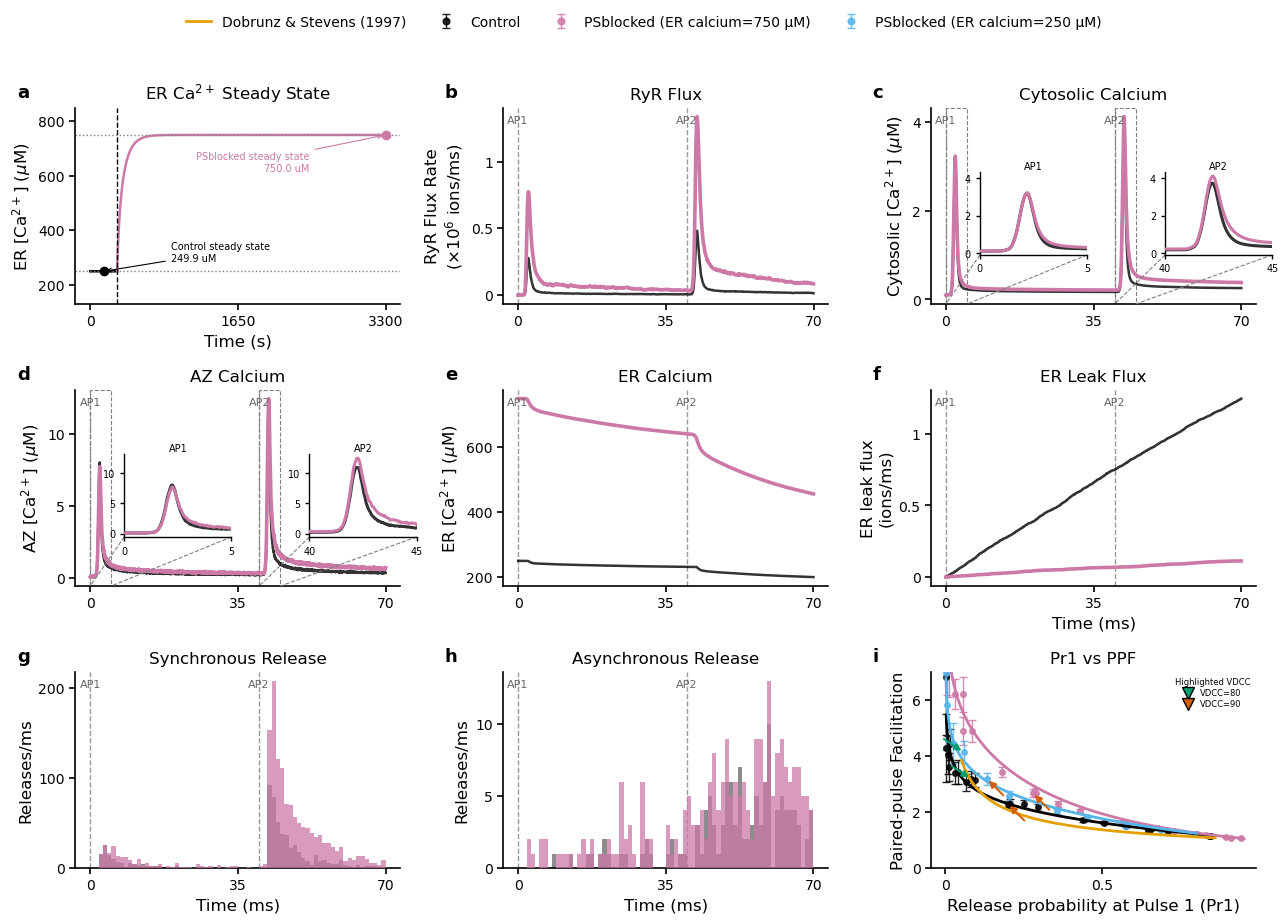

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()
letters = "abcdefghi"

# ---------------- (a) ER Ca2+ steady-state transition: Control -> PS-blocked ----------------
ax = axes[0]
ctrl_cond = get_condition("control")
ps_cond = get_condition("ad_ps_blocked")

pre_mask = T_TRANSITION_S <= SWITCH_TIME_S
post_mask = T_TRANSITION_S >= SWITCH_TIME_S

ax.plot(T_TRANSITION_S[pre_mask], CAE_TRANSITION_UM[pre_mask], color=ctrl_cond.color, lw=1.8,
        label=ctrl_cond.label)
ax.plot(T_TRANSITION_S[post_mask], CAE_TRANSITION_UM[post_mask], color=ps_cond.color, lw=1.8,
        label=ps_cond.label)
ax.axvline(SWITCH_TIME_S, color="k", ls="--", lw=1)
ax.axhline(CONTROL_STEADY_STATE_UM, color="gray", ls=":", lw=1)
ax.axhline(PS_BLOCKED_STEADY_STATE_UM, color="gray", ls=":", lw=1)

# Extra vertical headroom so both steady-state call-outs sit fully inside
# the axes instead of colliding with the title or the x-axis/tick labels.
ax.set_ylim(130, 850)

mid_idx = len(_t_control) // 2
ax.plot(T_TRANSITION_S[mid_idx], CONTROL_STEADY_STATE_UM, "o", color=ctrl_cond.color, zorder=5)
ax.annotate(f"Control steady state\n{CONTROL_STEADY_STATE_UM:.1f} uM",
            xy=(T_TRANSITION_S[mid_idx], CONTROL_STEADY_STATE_UM),
            xytext=(T_TRANSITION_S[mid_idx] + 750, CONTROL_STEADY_STATE_UM + 70),
            ha="left", va="center", color=ctrl_cond.color, fontsize=7,
            arrowprops=dict(arrowstyle="->", color=ctrl_cond.color, lw=0.8))

ax.plot(T_TRANSITION_S[-1], PS_BLOCKED_STEADY_STATE_UM, "o", color=ps_cond.color, zorder=5)
ax.annotate(f"PSblocked steady state\n{PS_BLOCKED_STEADY_STATE_UM:.1f} uM",
            xy=(T_TRANSITION_S[-1], PS_BLOCKED_STEADY_STATE_UM),
            xytext=(T_TRANSITION_S[-1] - 850, PS_BLOCKED_STEADY_STATE_UM - 100),
            ha="right", va="center", color=ps_cond.color, fontsize=7,
            arrowprops=dict(arrowstyle="->", color=ps_cond.color, lw=0.8))

ax.set_xlabel("Time (s)", fontsize=LABEL_FS)
ax.set_ylabel(r"ER [Ca$^{2+}$] ($\mu$M)", fontsize=LABEL_FS)
ax.set_title("ER Ca$^{2+}$ Steady State", fontsize=LABEL_FS)
strip_spines(ax)
set_n_ticks(ax, 0, T_TRANSITION_S[-1], n=3, axis="x")
label_panel(ax, letters[0])

# ---------------- (b) RyR flux ----------------

ax = axes[1]
for cond_key in DIRS:
    cond = get_condition(cond_key)
    t, y = TRACES[cond_key]["ryr_flux"]
    ax.plot(t * 1000, y * RYR_FLUX_SCALE, color=cond.color, lw=COND_LW[cond_key],
             alpha=cond.alpha, zorder=cond.zorder)
ax.set_ylabel("RyR Flux Rate\n" + r"($\times10^{6}$ ions/ms)", fontsize=LABEL_FS)
ax.set_title("RyR Flux", fontsize=LABEL_FS)
strip_spines(ax)
set_n_ticks(ax, 0, T_END * 1000, n=3, axis="x")
set_nice_ticks(ax, *ax.get_ylim(), n=3, axis="y")
mark_stimuli(ax, [T_STIM1_MS, T_STIM2_MS])
label_panel(ax, letters[1])

# ---------------- (c)-(e) Cytosolic / AZ / ER [Ca2+] ----------------
ca_panels = [
    (axes[2], "cyto_ca", "Cytosolic Calcium", r"Cytosolic [Ca$^{2+}$] ($\mu$M)", letters[2]),
    (axes[3], "az_ca",   "AZ Calcium",        r"AZ [Ca$^{2+}$] ($\mu$M)",        letters[3]),
    (axes[4], "er_ca",   "ER Calcium",        r"ER [Ca$^{2+}$] ($\mu$M)",        letters[4]),
]
for ax, key, title, ylabel, letter in ca_panels:
    for cond_key in DIRS:
        cond = get_condition(cond_key)
        t, y = TRACES[cond_key][key]
        ax.plot(t * 1000, y, color=cond.color, lw=COND_LW[cond_key], alpha=cond.alpha, zorder=cond.zorder)
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_title(title, fontsize=LABEL_FS)
    strip_spines(ax)
    set_n_ticks(ax, 0, T_END * 1000, n=3, axis="x")
    set_nice_ticks(ax, *ax.get_ylim(), n=3, axis="y")
    mark_stimuli(ax, [T_STIM1_MS, T_STIM2_MS])
    label_panel(ax, letter)


    if key in ("cyto_ca", "az_ca"):
        traces = [(TRACES[ck][key][0] * 1000, TRACES[ck][key][1], get_condition(ck)) for ck in DIRS]
        add_zoom_inset(ax, traces, (T_STIM1_MS, T_STIM1_MS + INSET_WINDOW_MS),
                        rect=(0.15, 0.25, 0.33, 0.42), show_yticklabels=True, title="AP1",
                        tick_fontsize=7, title_fontsize=7)
        add_zoom_inset(ax, traces, (T_STIM2_MS, T_STIM2_MS + INSET_WINDOW_MS),
                        rect=(0.72, 0.25, 0.33, 0.42), show_yticklabels=True, title="AP2",
                        tick_fontsize=7, title_fontsize=7)

# ---------------- (f) ER leak flux ----------------
ax = axes[5]
for cond_key in DIRS:
    cond = get_condition(cond_key)
    t, y = TRACES[cond_key]["er_leak"]
    ax.plot(t * 1000, y, color=cond.color, lw=COND_LW[cond_key], alpha=cond.alpha, zorder=cond.zorder)
ax.set_ylabel("ER leak flux\n(ions/ms)", fontsize=LABEL_FS)
ax.set_title("ER Leak Flux", fontsize=LABEL_FS)
strip_spines(ax)
set_n_ticks(ax, 0, T_END * 1000, n=3, axis="x")
set_nice_ticks(ax, *ax.get_ylim(), n=3, axis="y")
mark_stimuli(ax, [T_STIM1_MS, T_STIM2_MS])
label_panel(ax, letters[5])
ax.set_xlabel("Time (ms)", fontsize=LABEL_FS)

# ---------------- (g)-(h) Sync / async release ----------------
bin_size = 0.001  # 1 ms bins, matches Section 2's release histogram
for ax, relfile, title, letter in [(axes[6], "syncRel", "Synchronous Release", letters[6]),
                                    (axes[7], "asyncRel", "Asynchronous Release", letters[7])]:
    for cond_key, data_dir in DIRS.items():
        cond = get_condition(cond_key)
        ev = np.genfromtxt(data_dir / relfile, usecols=0)
        ev = ev[~np.isnan(ev)]
        bins = np.arange(0, T_END + bin_size, bin_size)
        counts, edges = np.histogram(ev, bins=bins)
        centers = (edges[:-1] + edges[1:]) / 2 * 1000
        bar_alpha = 0.75 if cond_key != "control" else 0.45
        ax.bar(centers, counts, width=bin_size * 1000, color=cond.color,
                alpha=bar_alpha, zorder=cond.zorder)
    ax.set_ylabel("Releases/ms", fontsize=LABEL_FS)
    ax.set_title(title, fontsize=LABEL_FS)
    strip_spines(ax)
    set_n_ticks(ax, 0, T_END * 1000, n=3, axis="x")
    set_nice_ticks(ax, *ax.get_ylim(), n=3, axis="y")
    mark_stimuli(ax, [T_STIM1_MS, T_STIM2_MS])
    label_panel(ax, letter)
    ax.set_xlabel("Time (ms)", fontsize=LABEL_FS)

# ---------------- (i) Pr(AP1) vs Facilitation (Section 6, compact) ----------------
ax = axes[8]
draw_pr_ppf_panel(ax, legend_fontsize=6, legend_compact=True, show_condition_legend=False,
                   xlabel="Release probability at Pulse 1 (Pr1)",
                   ylabel="Paired-pulse Facilitation")
ax.set_title("Pr1 vs PPF", fontsize=LABEL_FS)
label_panel(ax, letters[8])

handles, labels = axes[8].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           fontsize=LEG_FS + 1, markerscale=1.2, handlelength=1.8,
           bbox_to_anchor=(0.5, 1.03))

plt.tight_layout(rect=[0, 0, 1, 0.96])
if SAVE_FIGS:
    save_figure(fig, "fig4_PSblocked_paired_pulse.png")
plt.show()
